                           GDP_Growth  Revenue_GDP           Expenditure_GDP  \
count                              18         18.0                        18   
unique                             18         16.0                        18   
top     Tăng trưởng GDP thực hằng năm         23.9  Tổng chi NSNN so với GDP   
freq                                1          2.0                         1   

                    Inflation  \
count                      18   
unique                     18   
top     Lạm phát CPI hằng năm   
freq                        1   

                                             Balance_GDP  \
count                                                 18   
unique                                                18   
top     Cân đối ngân sách so với GDP = Thu/GDP - Chi/GDP   
freq                                                   1   

                          FDI_GDP                  Trade_Openness  
count                          18                              1

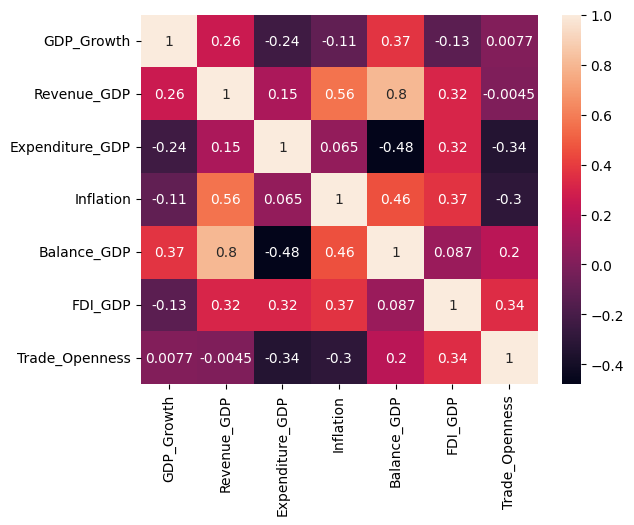

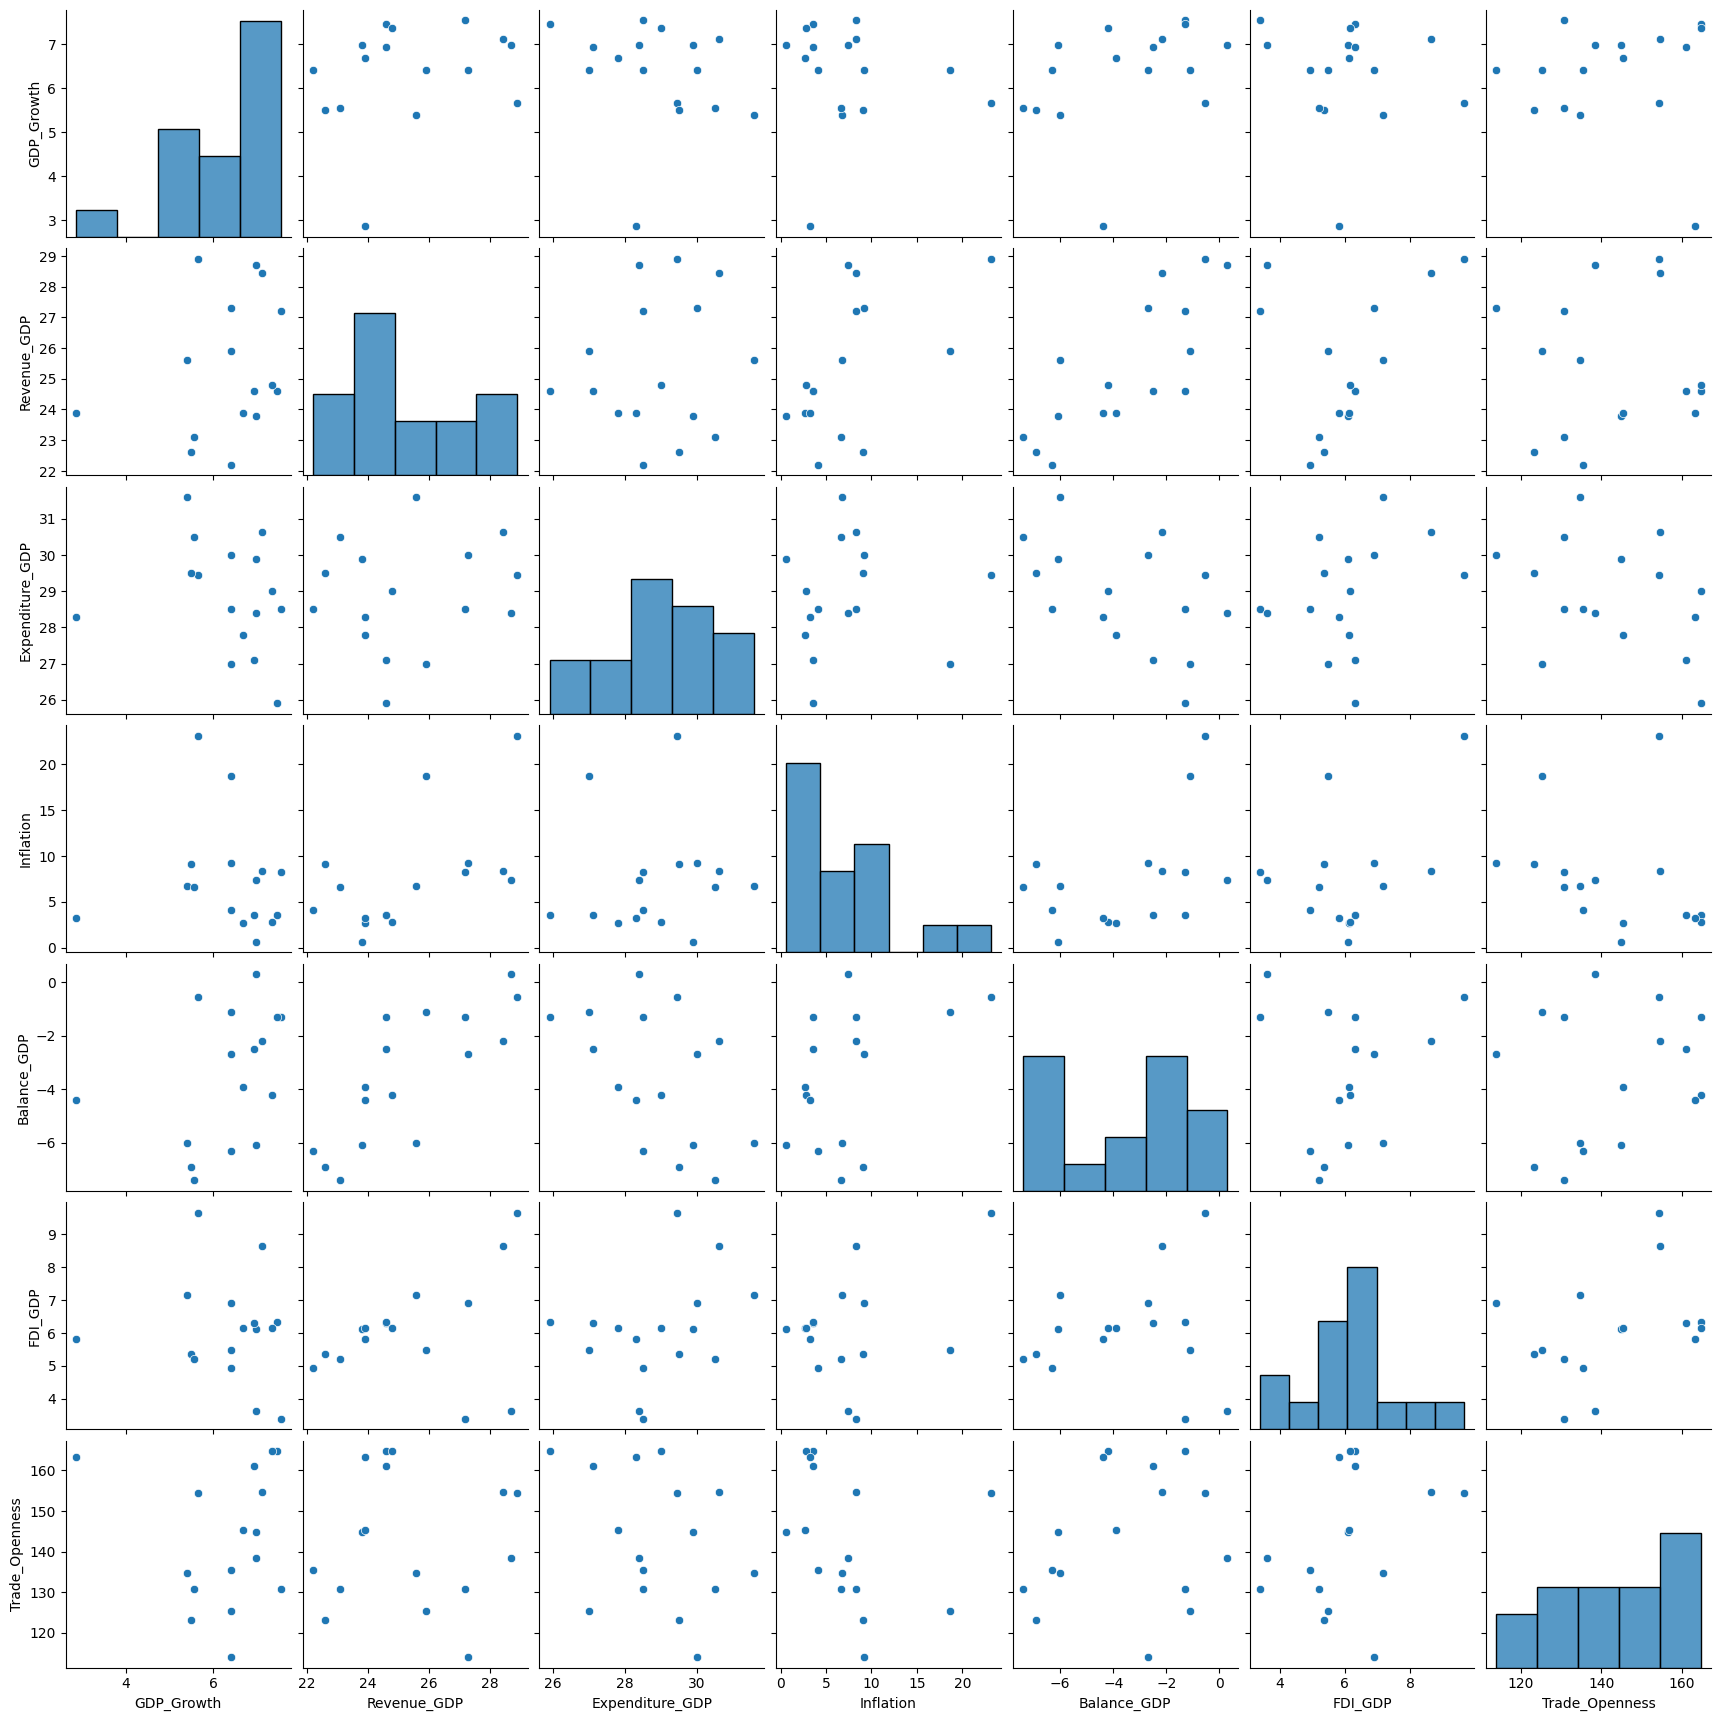

                            OLS Regression Results                            
Dep. Variable:             GDP_Growth   R-squared:                       0.304
Model:                            OLS   Adj. R-squared:                 -0.044
Method:                 Least Squares   F-statistic:                    0.8730
Date:                Sat, 16 May 2026   Prob (F-statistic):              0.532
Time:                        12:57:43   Log-Likelihood:                -21.768
No. Observations:                  16   AIC:                             55.54
Df Residuals:                      10   BIC:                             60.17
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const              12.9175     10.078     

In [ ]:
```python
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

from statsmodels.stats.outliers_influence import (
    variance_inflation_factor
)

from statsmodels.stats.diagnostic import (
    het_breuschpagan
)

from statsmodels.stats.stattools import (
    durbin_watson
)

# =========================================================
# 1. IMPORT DATA
# =========================================================

df = pd.read_excel(
    "MAT16A_Mo_hinh_OLS_FDI_Trade.xlsx",
    sheet_name="Data_2005_2020",
    header=3
)

# =========================================================
# 2. SELECT VARIABLES
# =========================================================

df = df[
    [
        "GDP_Growth",
        "Balance_GDP",
        "Inflation",
        "FDI_GDP",
        "Trade_Openness"
    ]
]

# =========================================================
# 3. CLEAN DATA
# =========================================================

df = df.apply(pd.to_numeric, errors="coerce")

# remove missing values
df = df.dropna()

print("\n==============================")
print("CLEAN DATA")
print("==============================")
print(df)

# =========================================================
# 4. DESCRIPTIVE STATISTICS
# =========================================================

print("\n==============================")
print("DESCRIPTIVE STATISTICS")
print("==============================")

desc = df.describe()

print(desc)

# =========================================================
# 5. CORRELATION MATRIX
# =========================================================

print("\n==============================")
print("CORRELATION MATRIX")
print("==============================")

corr = df.corr()

print(corr)

# =========================================================
# 6. HEATMAP
# =========================================================

plt.figure(figsize=(10, 7))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.show()

# =========================================================
# 7. PAIRPLOT / SCATTER MATRIX
# =========================================================

sns.pairplot(df)

plt.show()

# =========================================================
# 8. DEFINE Y AND X
# =========================================================

# dependent variable
y = df["GDP_Growth"]

# independent variables
X = df[
    [
        "Balance_GDP",
        "Inflation",
        "FDI_GDP",
        "Trade_Openness"
    ]
]

# add intercept
X = sm.add_constant(X)

# =========================================================
# 9. RUN OLS MODEL
# =========================================================

model = sm.OLS(y, X).fit()

print("\n==============================")
print("OLS REGRESSION RESULT")
print("==============================")

print(model.summary())

# =========================================================
# 10. EXTRACT OLS COMPONENTS
# =========================================================

beta_hat = model.params

y_hat = model.fittedvalues

residuals = model.resid

print("\n==============================")
print("ESTIMATED COEFFICIENTS")
print("==============================")

print(beta_hat)

# =========================================================
# 11. R-SQUARED
# =========================================================

print("\n==============================")
print("MODEL FIT")
print("==============================")

print("R-squared:", model.rsquared)

print("Adjusted R-squared:", model.rsquared_adj)

# =========================================================
# 12. F-STATISTIC
# =========================================================

print("\n==============================")
print("F-TEST")
print("==============================")

print("F-statistic:", model.fvalue)

print("Prob(F-statistic):", model.f_pvalue)

# =========================================================
# 13. VIF TEST
# =========================================================

print("\n==============================")
print("VIF TEST")
print("==============================")

vif = pd.DataFrame()

vif["Variable"] = X.columns

vif["VIF"] = [
    variance_inflation_factor(X.values, i)
    for i in range(X.shape[1])
]

print(vif)

# =========================================================
# 14. RESIDUAL HISTOGRAM
# =========================================================

plt.figure(figsize=(8, 5))

plt.hist(
    residuals,
    bins=10
)

plt.title("Histogram of Residuals")

plt.xlabel("Residual")

plt.ylabel("Frequency")

plt.show()

# =========================================================
# 15. RESIDUALS VS FITTED
# =========================================================

plt.figure(figsize=(8, 5))

plt.scatter(
    y_hat,
    residuals
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.xlabel("Fitted Values")

plt.ylabel("Residuals")

plt.title("Residuals vs Fitted Values")

plt.show()

# =========================================================
# 16. HETEROSKEDASTICITY TEST
# Breusch-Pagan Test
# =========================================================

print("\n==============================")
print("BREUSCH-PAGAN TEST")
print("==============================")

bp_test = het_breuschpagan(
    residuals,
    model.model.exog
)

bp_labels = [
    "LM Statistic",
    "LM-Test p-value",
    "F-Statistic",
    "F-Test p-value"
]

bp_results = dict(zip(bp_labels, bp_test))

print(bp_results)

# =========================================================
# 17. DURBIN-WATSON TEST
# =========================================================

print("\n==============================")
print("DURBIN-WATSON TEST")
print("==============================")

dw = durbin_watson(residuals)

print("Durbin-Watson:", dw)

# =========================================================
# 18. OUTLIER DETECTION
# =========================================================

influence = model.get_influence()

# standardized residuals
standardized_residuals = (
    influence.resid_studentized_internal
)

print("\n==============================")
print("STANDARDIZED RESIDUALS")
print("==============================")

print(standardized_residuals)

# Cook's Distance
cooks_distance = influence.cooks_distance[0]

print("\n==============================")
print("COOK'S DISTANCE")
print("==============================")

print(cooks_distance)

plt.figure(figsize=(8, 5))

plt.stem(cooks_distance)

plt.title("Cook's Distance")

plt.xlabel("Observation")

plt.ylabel("Cook's Distance")

plt.show()

# =========================================================
# 19. SUMMARY INTERPRETATION
# =========================================================

print("\n==============================")
print("INTERPRETATION GUIDE")
print("==============================")

print("""
1. Check R-squared and Adjusted R-squared
   -> model explanatory power

2. Check Prob(F-statistic)
   -> if p < 0.05:
      model is statistically significant

3. Check p-value of each coefficient
   -> if p < 0.05:
      variable is statistically significant

4. Check VIF
   -> VIF > 10:
      multicollinearity problem

5. Check Breusch-Pagan test
   -> p < 0.05:
      heteroskedasticity exists

6. Check Durbin-Watson
   -> around 2:
      no serious autocorrelation

7. Check residual plots
   -> residuals should scatter randomly
""")



In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

from statsmodels.stats.outliers_influence import (
    variance_inflation_factor
)

from statsmodels.stats.diagnostic import (
    het_breuschpagan
)

from statsmodels.stats.stattools import (
    durbin_watson
)

# =========================================================
# 1. IMPORT & CLEAN DATA
# =========================================================

df = pd.read_excel(
    "MAT16A_Mo_hinh_OLS_FDI_Trade.xlsx",
    sheet_name="Data_2005_2020",
    header=3
)

df = df[
    [
        "GDP_Growth",
        "Balance_GDP",
        "Inflation",
        "FDI_GDP",
        "Trade_Openness"
    ]
]

df = df.apply(pd.to_numeric, errors="coerce")

df = df.dropna()

# =========================================================
# 2. DESCRIPTIVE STATISTICS
# =========================================================

desc = df.describe()

print("\n==============================")
print("DESCRIPTIVE STATISTICS")
print("==============================")

print(desc)

# =========================================================
# 3. CORRELATION MATRIX
# =========================================================

corr = df.corr()

print("\n==============================")
print("CORRELATION MATRIX")
print("==============================")

print(corr)

# =========================================================
# 4. HEATMAP
# =========================================================

plt.figure(figsize=(10, 7))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.show()

# =========================================================
# 5. PAIRPLOT
# =========================================================

sns.pairplot(df)

plt.show()

# =========================================================
# 6. DEFINE MODEL
# =========================================================

y = df["GDP_Growth"]

X = df[
    [
        "Balance_GDP",
        "Inflation",
        "FDI_GDP",
        "Trade_Openness"
    ]
]

X = sm.add_constant(X)

# =========================================================
# 7. RUN OLS
# =========================================================

model = sm.OLS(y, X).fit()

print("\n==============================")
print("OLS REGRESSION RESULT")
print("==============================")

print(model.summary())

# =========================================================
# 8. MODEL FIT
# =========================================================

print("\n==============================")
print("MODEL FIT")
print("==============================")

print(f"R-squared           : {model.rsquared:.4f}")

print(f"Adjusted R-squared  : {model.rsquared_adj:.4f}")

print(f"F-statistic         : {model.fvalue:.4f}")

print(f"Prob(F-statistic)   : {model.f_pvalue:.4f}")

# =========================================================
# 9. VIF TEST
# =========================================================

vif = pd.DataFrame()

vif["Variable"] = X.columns

vif["VIF"] = [
    variance_inflation_factor(X.values, i)
    for i in range(X.shape[1])
]

print("\n==============================")
print("VIF TEST")
print("==============================")

print(vif)

# =========================================================
# 10. RESIDUAL ANALYSIS
# =========================================================

residuals = model.resid

fitted = model.fittedvalues

# Histogram residuals
plt.figure(figsize=(8, 5))

plt.hist(
    residuals,
    bins=10
)

plt.title("Histogram of Residuals")

plt.xlabel("Residuals")

plt.ylabel("Frequency")

plt.show()

# Residuals vs fitted
plt.figure(figsize=(8, 5))

plt.scatter(
    fitted,
    residuals
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.xlabel("Fitted Values")

plt.ylabel("Residuals")

plt.title("Residuals vs Fitted Values")

plt.show()

# =========================================================
# 11. BREUSCH-PAGAN TEST
# =========================================================

bp_test = het_breuschpagan(
    residuals,
    model.model.exog
)

bp_labels = [
    "LM Statistic",
    "LM-Test p-value",
    "F-Statistic",
    "F-Test p-value"
]

bp_results = dict(zip(bp_labels, bp_test))

print("\n==============================")
print("BREUSCH-PAGAN TEST")
print("==============================")

print(bp_results)

# =========================================================
# 12. DURBIN-WATSON TEST
# =========================================================

dw = durbin_watson(residuals)

print("\n==============================")
print("DURBIN-WATSON TEST")
print("==============================")

print(f"Durbin-Watson : {dw:.4f}")

# =========================================================
# 13. OUTLIER DETECTION
# =========================================================

influence = model.get_influence()

# standardized residuals
standardized_residuals = (
    influence.resid_studentized_internal
)

print("\n==============================")
print("STANDARDIZED RESIDUALS")
print("==============================")

print(standardized_residuals)

# Cook's Distance
cooks_distance = influence.cooks_distance[0]

print("\n==============================")
print("COOK'S DISTANCE")
print("==============================")

print(cooks_distance)

plt.figure(figsize=(8, 5))

plt.stem(cooks_distance)

plt.title("Cook's Distance")

plt.xlabel("Observation")

plt.ylabel("Cook's Distance")

plt.show()
